# Méthodes Directes

D'abord quelques exemples d'utilisations de la factorisation LU et de Choleski, ensuite on passe aux methodes itéreatives

## Exercice 

On considère le système linéaire $A\mathbf{x} = \mathbf{b}$ où :

$$A = \left(
  \begin{array}{ccc}
          3 & 6 & 7 \\[0.5em]
          1 & 1 & 4 \\[0.5em]
          2 & 4 & 8
        \end{array} \right), \quad
  \mathbf{b} = \left( \begin{array}{c} 4 \\[0.5em] 5 \\[0.5em] 6 \end{array} 
\right) \, .$$
      
1. Calculer la factorisation $LU$ de la matrice $A$ avec Python:

2. Résoudre le système linéaire $A \mathbf{x} = \mathbf{b}$ en utilisant la factorisation trouvée au point
précédent (Ne plus utiliser Python. Mais ici on va le faire)

3. Calculer le déterminant de la matrice $A$ en utilisant sa factorisation $LU$.

In [1]:
# importing libraries used in this book
import numpy as np
import matplotlib.pyplot as plt

# scipy.linalg.eigh : eigenvalues for symmetric matric
from scipy.linalg import eigh
# scipy.linalg.eig : eigenvalues of a matrix
from scipy.linalg import eig
# scipy.linalg.det : determinant of a matrix
from scipy.linalg import det
# scipy.linalg.lu : LU decomposition
from scipy.linalg import lu
# scipy.linalg.cholesky : Cholesky decomposition
from scipy.linalg import cholesky
from scipy.linalg import hilbert

import pprint

#### Partie 1

In [2]:
A = np.array([[3, 6, 7],
              [1, 1, 4],
              [2, 4, 8] ])

# LU factorisation with pivoting
P, L, U = lu(A)

print("A = P L U")
pprint.pprint(P.dot(L.dot(U)) )

print("P:")
pprint.pprint(P)

print ("L:")
pprint.pprint(L)

print ("U:")
pprint.pprint(U)


A = P L U
array([[3., 6., 7.],
       [1., 1., 4.],
       [2., 4., 8.]])
P:
array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])
L:
array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 3.33333333e-01,  1.00000000e+00,  0.00000000e+00],
       [ 6.66666667e-01, -2.22044605e-16,  1.00000000e+00]])
U:
array([[ 3.        ,  6.        ,  7.        ],
       [ 0.        , -1.        ,  1.66666667],
       [ 0.        ,  0.        ,  3.33333333]])


#### Partie 2

Si $P$ est l'identité, $A = LU$.

1. résoudre pour $\mathbf y$ tel que $L \mathbf y = \mathbf{b}$ par substitution progressive

2. résoudre pour $\mathbf x$ tel que $U \mathbf x = \mathbf{y}$ par substitution retrograde

Si $P$ n'est pas l'identité, $A = PLU$. 

Attention, une matrice de permutation est une matrice orthogonale car les colonnes sont orthonormée.
Donc $P^{-1} = P^T$. Du coup : $P^TA = LU$ et 
$$A\mathbf x = \mathbf b \Leftrightarrow P^TA\mathbf x = P^T \mathbf b\Leftrightarrow LU\mathbf x = P^T \mathbf b.$$
Alors il faut modifier les calculs précedants comme suit:

1. résoudre pour $\mathbf y$ tel que $L \mathbf y = P^T\mathbf{b}$ par substitution progressive

2. résoudre pour $\mathbf x$ tel que $U \mathbf x = \mathbf{y}$ par substitution retrograde


In [3]:
# to complete
b = np.array([3,3,1])
y = np.linalg.solve(L,b)
x = np.linalg.solve(U,y)

print(x)

# check the residual of the equation
print(b - A.dot(x))

[ 6.7 -2.5 -0.3]
[ 4.4408921e-16  0.0000000e+00 -4.4408921e-16]


#### Partie 3

$$\det A = \det P \, \det L \, \det U$$

In [4]:
# to complete

P,L,U = lu(A)
print(det(P)*det(L)*det(U))

-10.0


*Les mineurs principaux** d'une matrice $A \in \mathbb{R}^{n \times n}$ 
sont les déterminants des matrices $A_p = (a_{i,j})_{1 \leq i, j \leq p}$, $p = 1, ..., n$.

**Critère de Sylvester:** une matrice symétrique $A \in \mathbb{R}^{n\times n}$ 
est définie positive si et seulement si les mineurs
principaux de $A$ sont tous positifs.

## Exercice 

On considère le système linéaire $A\mathbf{x} = \mathbf{b}$
où

$$A = \left(
  \begin{array}{ccc}
  \varepsilon & 1 & 2\\
  1 & 3 & 1 \\
  2 & 1 & 3 \\
  \end{array}
  \right).$$
  
1. Déterminer pour quelles valeurs du paramètre réel
$\varepsilon \in \mathbb{R}$, la matrice $A$ est symétrique
définie positive 

2. Soit maintenant $\varepsilon=0$. On veut résoudre le système
$A\mathbf{x}=\mathbf{b}$ par une méthode directe; quelle
factorisation de la matrice $A$ envisageriez-vous? Justifier
votre réponse.

3. En considérant $\varepsilon = 2$, vérifier que dans ce cas la
matrice $A$ est définie positive et calculer sa
factorisation de Cholesky $A = L L^T$.

4. En supposant que $\mathbf{b} = (1,1,1)^T$, résoudre le
système linéaire $A \mathbf{x} = \mathbf{b}$ en utilisant la
factorisation de Cholesky calculée au point c).

Reference Python pour la factorisation de Cholesky :
[scipy.linalg.cholesky](https://docs.scipy.org/doc/scipy-0.15.1/reference/generated/scipy.linalg.cholesky.html)

#### Partie 1 et 2

cf corrigé de la série

#### Partie 3

In [5]:
epsilon = 2
A = np.array([[epsilon, 1, 2],
              [1, 3, 1],
              [2, 1, 3] ])

# Is A symmetric ?
print(f'max(abs(A-AT)) = {np.max(np.abs(A-A.T))} ')

# What are the eigenvlues of $A$ ? (usually, use eig, but here A is symmetric, we can use eigh )
lk, v = eigh(A)
print(f'The eigenvalues of A are {lk}')

# Cholesky factorisation: lower : return lower-triangular matrix, A = L L^T
L = cholesky(A, lower=True) 
print(f"\n A = L^T L = {L.dot(L.T)}\n")

print (f"L = {L}")



max(abs(A-AT)) = 0 
The eigenvalues of A are [0.42422653 2.18728373 5.38848975]

 A = L^T L = [[2. 1. 2.]
 [1. 3. 1.]
 [2. 1. 3.]]

L = [[1.41421356e+00 0.00000000e+00 0.00000000e+00]
 [7.07106781e-01 1.58113883e+00 0.00000000e+00]
 [1.41421356e+00 1.12135832e-16 1.00000000e+00]]


#### Partie 4

In [6]:
# to complete

x = np.linalg.solve(L,np.array([1,1,1]))
print(x)

[7.07106781e-01 3.16227766e-01 1.86584141e-16]


## Problèmes de précision

Les erreurs d'arrondis peuvent causer des différences importantes
entre la solution calculée par la méthode d'élimination de Gauss (MEG)
et la solution exacte. Cela arrive si le
*conditionnement* de la matrice du système est très grand.

La matrice de Hilbert de taille $n\times n$ est une matrice
symétrique définie par

$$a_{ij} = \frac{1}{i+j-1}, \qquad i,j=1,\ldots,n$$

On peut construire une matrice de Hilbert de taille $n$
quelconque en utilisant la commande `A = scipy.linalg.hilbert(n)`. Par
example, pour $n = 4$, on a:
$$A = \begin{bmatrix}
    1 & \frac{1}{2} & \frac{1}{3} & \frac{1}{4} \\
    \frac{1}{2} & \frac{1}{3} & \frac{1}{4} & \frac{1}{5} \\
    \frac{1}{3} & \frac{1}{4} & \frac{1}{5} & \frac{1}{6} \\
    \frac{1}{4} & \frac{1}{5} & \frac{1}{6} & \frac{1}{7}
\end{bmatrix}$$

On considère les systèmes linéaires $A_n \mathbf   {x}_n=\mathbf   {b}_n$ ou $A_n$ est la matrice de Hilbert de taille
$n$ avec $n=4,6,8,10,12,14,\ldots, 20$ tandis que $\mathbf   {b}_n$ est choisi de sorte que la solution exacte soit $\mathbf{x}_n= (1,1,\cdots, 1)^T$.

1. Pour chaque $n$, calculez le conditionnement de la matrice

2. Résolvez le système linéaire par la factorisation $LU$ et notez $\vec{x}^{LU}_n$ la solution calculée.

3. Dessinez le graphique avec le conditionnement obtenu ainsi que l'erreur rélatif
   $\Vert \mathbf    x_n -\mathbf    x^{LU}_n\Vert/\Vert \mathbf    x_n\Vert$ (où $\Vert\cdot\Vert$
   est la norme euclidienne d'un vecteur, 
   $\Vert\mathbf   {x}\Vert = \sqrt{\mathbf   {x}^T\cdot\mathbf   {x}}$). Utilisez ue échelle logarithmique pour l'axe $y$.
   
4. Sur le même graphique, reportez le conditionnement de la matrice $A$, `np.linalg.cond(A)`

Repetez la même chose avec la factorisation de Cholesky `L = cholesky(A, lower=True)` pour $n=4,6,8,10,12$. Que se passe-t-il si $n=14$


In [7]:
Nrange = range(2,20,2)
err = []
cond = []

for n in Nrange :
    A = hilbert(n)
    P, L, U = lu(A)

    x = np.ones([n,1])

    b = A.dot(x)

    # to complete (2-3 lines)
    xLU = np.linalg.solve(U,np.linalg.solve(L,np.linalg.solve(P,b)))
    

    err.append( np.linalg.norm(x-xLU) / np.linalg.norm(x) )
    cond.append( np.linalg.cond(A) )



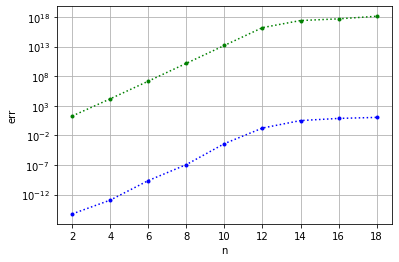

In [8]:

plt.plot(Nrange, err, 'b:.',Nrange, cond, 'g:.')

plt.xlabel('n'); plt.ylabel('err');
# plt.xscale('log') 
plt.yscale('log')
plt.grid(True)
plt.show()


In [9]:
Nrange = range(2,13,2)
err = []
cond = []

for n in Nrange :
    A = hilbert(n)
    L = cholesky(A, lower=True)

    x = np.ones([n,1])

    b = A.dot(x)

    # to complete (2 lines)

    xCho = np.linalg.solve(L,b)

    err.append( np.linalg.norm(x-xCho) / np.linalg.norm(x) )
    cond.append( np.linalg.cond(A) )



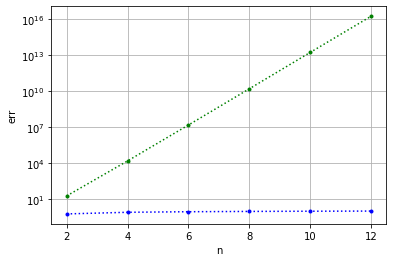

In [10]:

plt.plot(Nrange, err, 'b:.',Nrange, cond, 'g:.')

plt.xlabel('n'); plt.ylabel('err');
# plt.xscale('log') 
plt.yscale('log')
plt.grid(True)
plt.show()


In [12]:
n = 14
A = hilbert(n)
#L = cholesky(A, lower=True)
lk, v = eigh(A)

print(f'lk[0] = {lk[0]:0.5e} , the matrix is not positive definite. Let''s verify with the first eigenvector')

lk[0] = -9.13148e-18 , the matrix is not positive definite. Lets verify with the first eigenvector


La première valeur propre est négative, cela signifie que $(\mathbf v, A\mathbf v) = (\mathbf v, \lambda\mathbf v) = \lambda (\mathbf v, \mathbf v) = \lambda \|\mathbf v\|^2<0$, où $\mathbf v$ est le vecteur propre associé à cette valeur propre $\lambda$ négative.

Vérifions:

In [13]:
print ( A.dot(v[0]).T.dot(v[0]) )

0.007555533559357492


Pourquoi ? En vérité, le calcul des valeurs et vecteurs propres de $A$ a aussi un problème d'arrondi à cause du conditionnement. On peut en effet vérifier que le rapport entre les composantes de $\mathbf v$ et $A\mathbf v$ n'est ni égale à $\lambda$, ni une autre constante :

In [14]:
print(v[0]/A.dot(v[0]) )

[-0.00000000e+00 -0.00000000e+00 -1.17144619e-05  1.06847602e-04
 -8.09659339e-04  5.22487621e-03 -2.91724443e-02  1.42056758e-01
 -6.04409530e-01 -2.23639254e+00  7.09564293e+00  1.86749772e+01
 -3.71358584e+01  4.00708471e+01]
